In [198]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [199]:
data=pd.read_csv("Student_performance_data _.csv")
df=pd.DataFrame(data)
df

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


In [200]:
df=df.drop(["StudentID","Age","Gender","GPA"],axis=1)

In [201]:
df.isna().sum()

Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GradeClass           0
dtype: int64

In [202]:
df.duplicated().sum()
df[df.duplicated()]

,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GradeClass


In [203]:
df

,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GradeClass
0,0,2,19.833723,7,1,2,0,0,1,0,2.0
1,0,1,15.408756,0,0,1,0,0,0,0,1.0
2,2,3,4.210570,26,0,2,0,0,0,0,4.0
3,0,3,10.028829,14,0,3,1,0,0,0,3.0
4,0,2,4.672495,17,1,3,0,0,0,0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
2387,0,3,10.680555,2,0,4,1,0,0,0,0.0
2388,0,1,7.583217,4,1,4,0,1,0,0,4.0
2389,0,2,6.805500,20,0,2,0,0,0,1,2.0
2390,1,0,12.416653,17,0,2,0,1,1,0,1.0


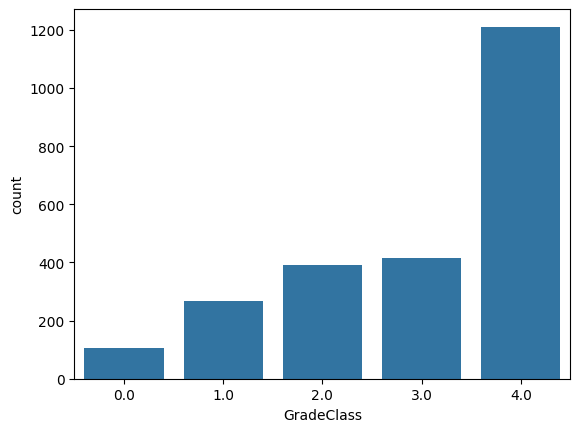

In [204]:
sns.countplot(x="GradeClass",data=df)
plt.show()

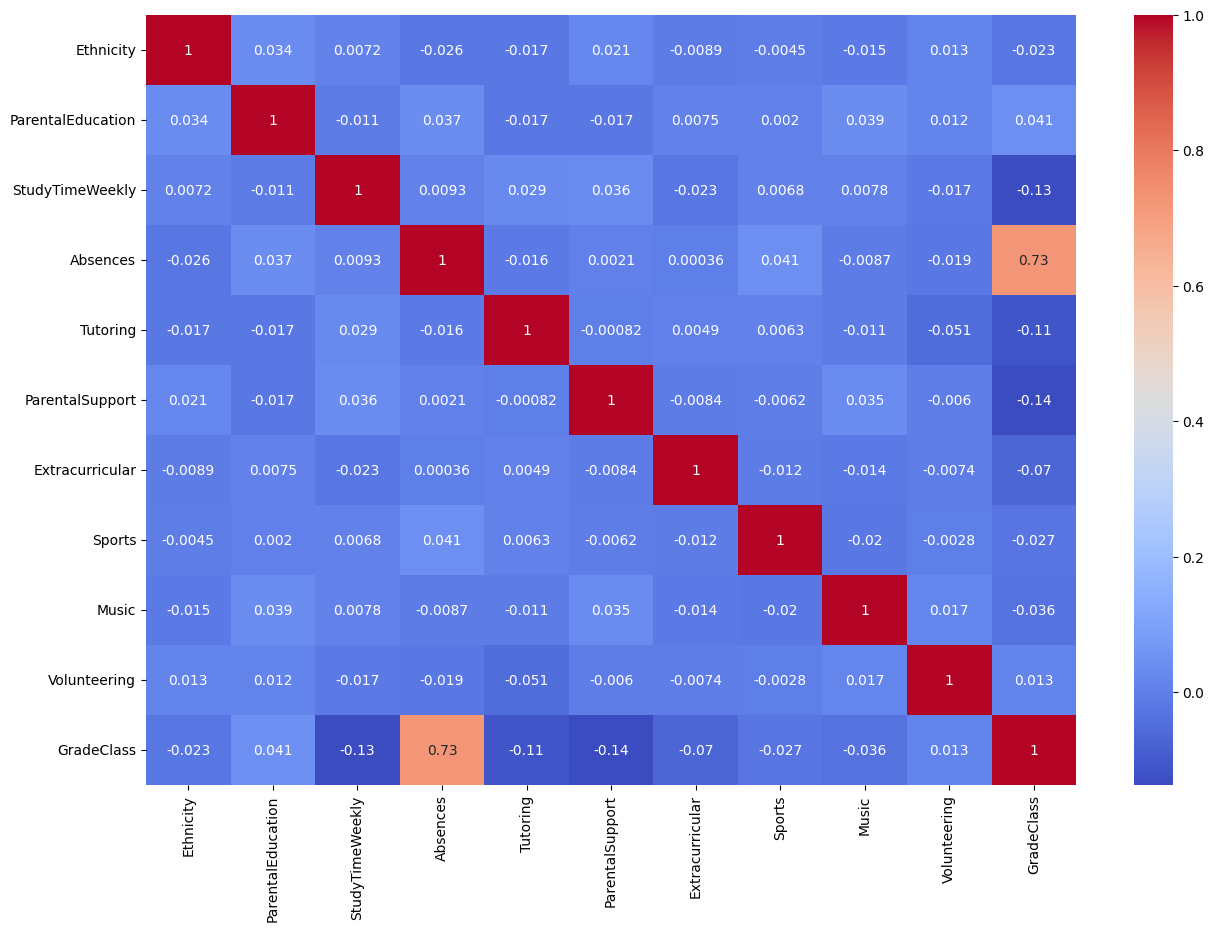

In [205]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

In [206]:
X=df.drop("GradeClass",axis=1)
y=df["GradeClass"]

In [207]:
X.dtypes

Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
dtype: object

In [208]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [209]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [210]:
X_train

array([[0.66666667, 0.75      , 0.13361613, ..., 0.        , 0.        ,
        0.        ],
       [0.66666667, 0.        , 0.22285227, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.5       , 0.58680325, ..., 0.        , 1.        ,
        1.        ],
       ...,
       [0.        , 0.25      , 0.69044142, ..., 0.        , 1.        ,
        1.        ],
       [0.        , 0.5       , 0.45463662, ..., 1.        , 0.        ,
        0.        ],
       [0.        , 0.5       , 0.64348803, ..., 0.        , 0.        ,
        0.        ]], shape=(1674, 10))

In [211]:
X_test

array([[0.33333333, 0.5       , 0.90216059, ..., 1.        , 1.        ,
        0.        ],
       [0.        , 1.        , 0.6959759 , ..., 0.        , 0.        ,
        1.        ],
       [0.        , 0.25      , 0.67032805, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.33808333, ..., 0.        , 0.        ,
        0.        ],
       [0.33333333, 0.25      , 0.17933274, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.30351519, ..., 1.        , 0.        ,
        0.        ]], shape=(718, 10))

In [212]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [213]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.5793871866295265


In [214]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[  7   8  10   2   5]
 [ 10  18  31  11  11]
 [  2  20  55  26  14]
 [  4  13  38  33  36]
 [  1   9  22  29 303]]


In [215]:
from sklearn.metrics import recall_score
print(recall_score(y_test,y_pred,average="weighted"))

0.5793871866295265
